In [1]:

!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN


!pip install basicsr facexlib gfpgan -q
!pip install -r requirements.txt -q
!python setup.py develop

# Baixar o modelo pré-treinado Real-ESRGAN x4 anime
!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.2.4/RealESRGAN_x4plus_anime_6B.pth -P weights
# versao normal

!wget https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth -P weights

Cloning into 'Real-ESRGAN'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 759 (delta 106), reused 99 (delta 99), pack-reused 638 (from 1)
Receiving objects: 100% (759/759), 5.38 MiB | 9.41 MiB/s, done.
Resolving deltas: 100% (415/415), done.
/content/Real-ESRGAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 18.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.7 MB/s eta

In [2]:
from google.colab import files
uploaded = files.upload()


Saving tamanho_original.jpeg to tamanho_original.jpeg


In [3]:
!pip install torch torchvision --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [4]:
# Corrigir a importação errada no arquivo da biblioteca basicsr
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/' /usr/local/lib/python3.11/dist-packages/basicsr/data/degradations.py


In [19]:
# 4x upscaling
!python inference_realesrgan.py -n RealESRGAN_x4plus_anime_6B -i /content/entrada -o /content/resultado --face_enhance --fp32
# 16x upscaling usando 200x200 pixel para o processamento -> divir e conquistar pelo tamanho de memoria da gpu
!python inference_realesrgan.py -n RealESRGAN_x4plus -i /content/resultado/tamanho_original_out.jpeg -o /content/resultado/16x --tile 200 --face_enhance --fp32


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Testing 0 tamanho_original
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to 

In [6]:
from google.colab import files
files.download('results/images_out.jpeg')


FileNotFoundError: Cannot find file: results/images_out.jpeg

bicubic

In [8]:
from PIL import Image


img = Image.open("/content/tamanho_original.jpeg")

bicubic_img = img.resize((img.width * 4, img.height * 4), Image.BICUBIC)


bicubic_img.save("interpolada_bicubic.jpeg")
files.download("interpolada_bicubic.jpeg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3442: DecompressionBombWarning: Image size (139356160 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


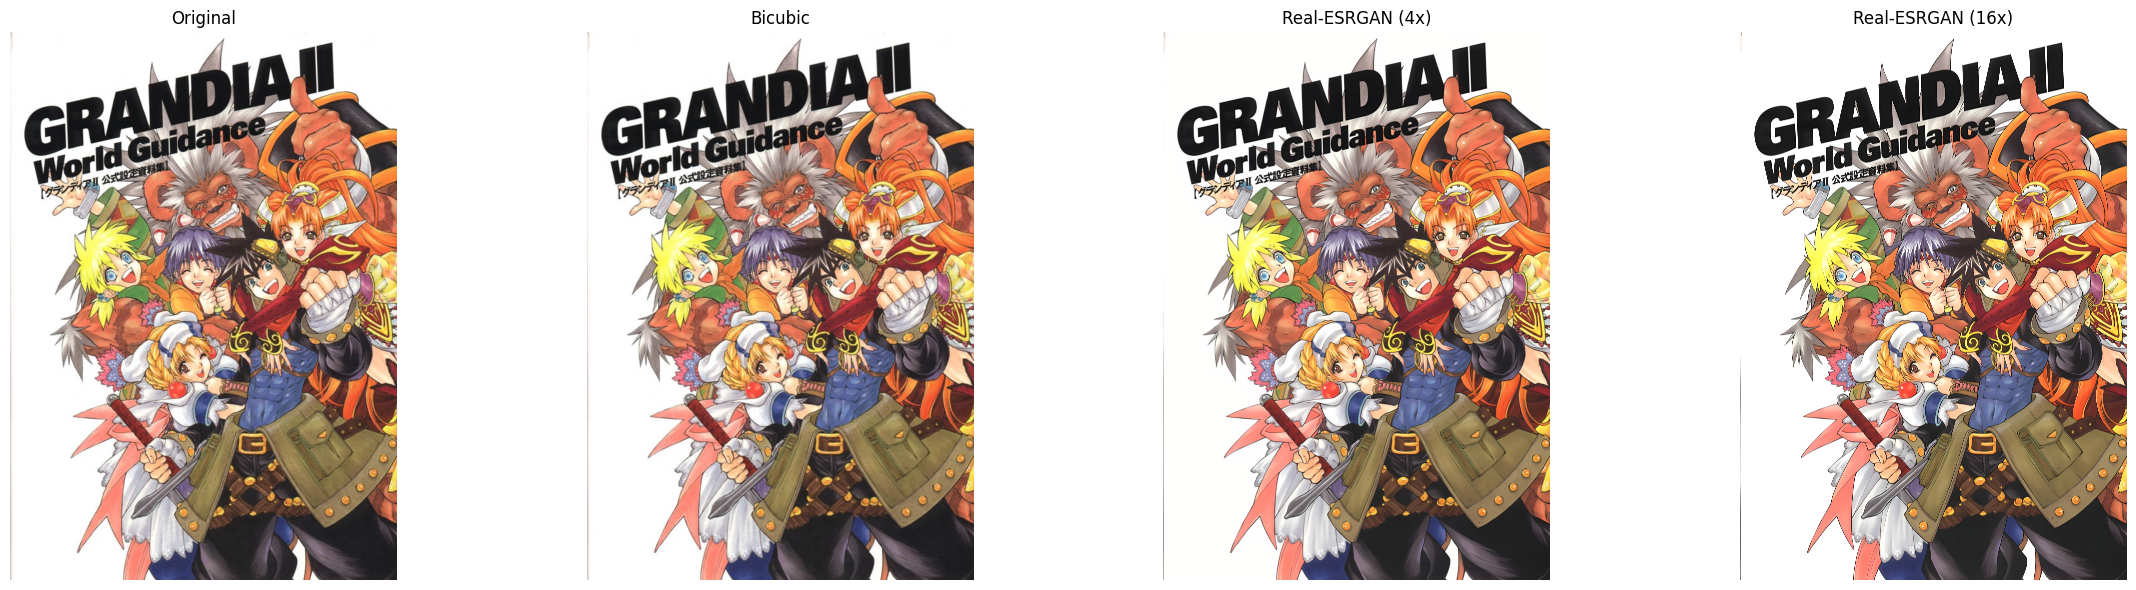

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

# Abrir as imagens
img_original = Image.open("/content/entrada/tamanho_original.jpeg")
img_bicubic = Image.open("/content/bicubic.jpeg")
img_sr_4x = Image.open("/content/resultado/tamanho_original_out.jpeg")  # 4x
img_sr_16x = Image.open("/content/resultado/16x/tamanho_original_out_out.jpeg")  # 16x (nova imagem)

# Criar o plot
plt.figure(figsize=(24, 6))  # mais largura para 4 imagens

# Imagem 1: original
plt.subplot(1, 4, 1)
plt.imshow(img_original)
plt.title("Original")
plt.axis('off')

# Imagem 2: bicubic
plt.subplot(1, 4, 2)
plt.imshow(img_bicubic)
plt.title("Bicubic")
plt.axis('off')

# Imagem 3: Real-ESRGAN (4x)
plt.subplot(1, 4, 3)
plt.imshow(img_sr_4x)
plt.title("Real-ESRGAN (4x)")
plt.axis('off')

# Imagem 4: Real-ESRGAN (16x)
plt.subplot(1, 4, 4)
plt.imshow(img_sr_16x)
plt.title("Real-ESRGAN (16x)")
plt.axis('off')

plt.tight_layout()
plt.show()


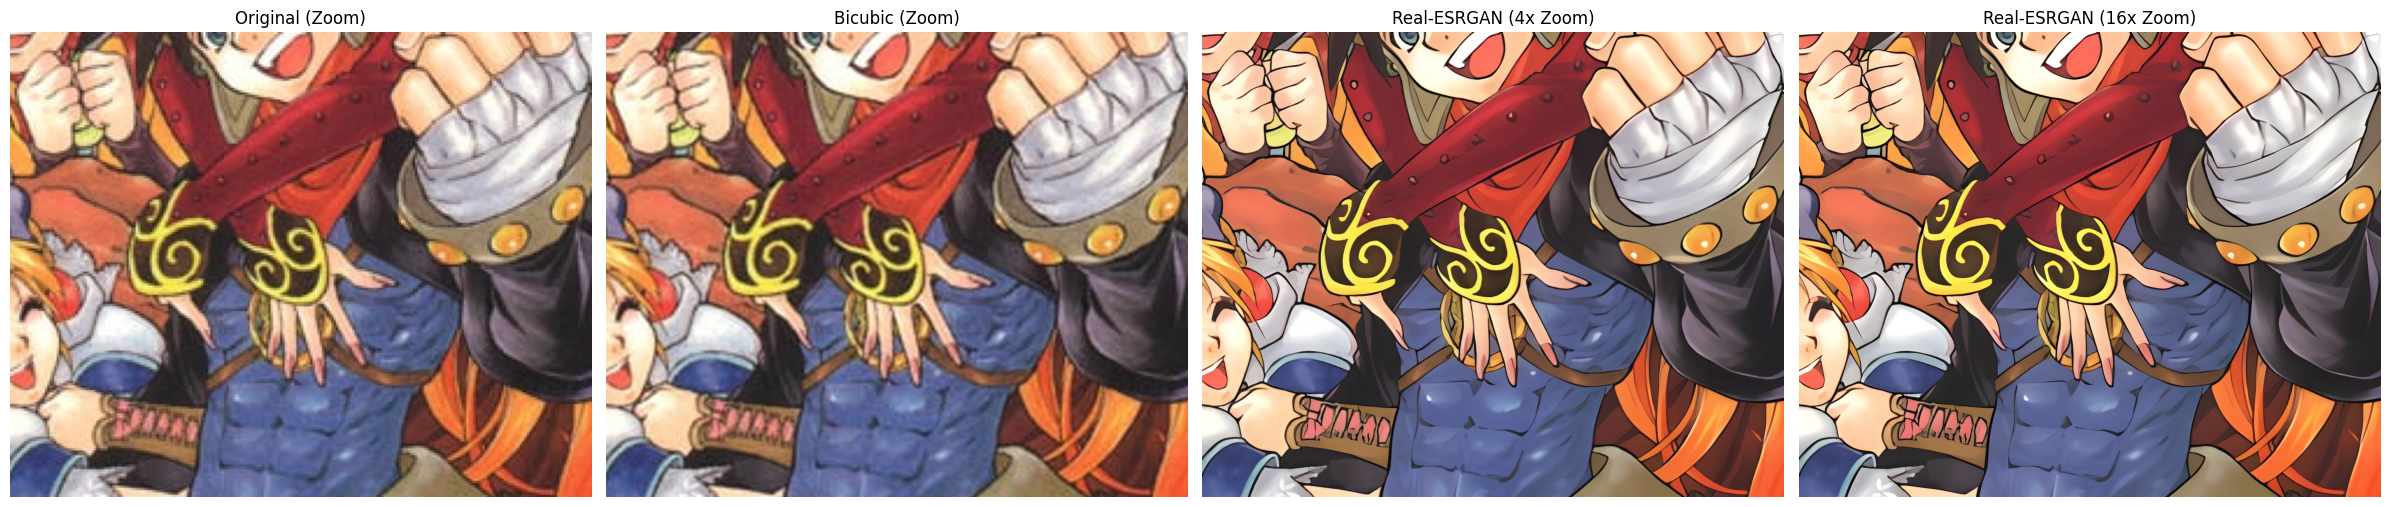

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Abrir imagens
original = Image.open("/content/entrada/tamanho_original.jpeg")
bicubic = Image.open("/content/bicubic.jpeg")
sr_4x = Image.open("/content/resultado/tamanho_original_out.jpeg")
sr_16x = Image.open("/content/resultado/16x/tamanho_original_out_out.jpeg")  # Adicione aqui

# Define a região de interesse (crop) na imagem original
crop_box_original = (300, 400, 550, 600)

# Fatores de escala
factor_bicubic_x = bicubic.width / original.width
factor_bicubic_y = bicubic.height / original.height

factor_sr4_x = sr_4x.width / original.width
factor_sr4_y = sr_4x.height / original.height

factor_sr16_x = sr_16x.width / original.width
factor_sr16_y = sr_16x.height / original.height

# Caixas de recorte ajustadas
crop_box_bicubic = tuple(int(crop_box_original[i] * (factor_bicubic_x if i % 2 == 0 else factor_bicubic_y)) for i in range(4))
crop_box_sr4 = tuple(int(crop_box_original[i] * (factor_sr4_x if i % 2 == 0 else factor_sr4_y)) for i in range(4))
crop_box_sr16 = tuple(int(crop_box_original[i] * (factor_sr16_x if i % 2 == 0 else factor_sr16_y)) for i in range(4))

# Corta as regiões
zoom_original = original.crop(crop_box_original)
zoom_bicubic = bicubic.crop(crop_box_bicubic)
zoom_sr4 = sr_4x.crop(crop_box_sr4)
zoom_sr16 = sr_16x.crop(crop_box_sr16)

# Exibe o zoom comparativo
plt.figure(figsize=(24, 6))
titles = ["Original (Zoom)", "Bicubic (Zoom)", "Real-ESRGAN (4x Zoom)", "Real-ESRGAN (16x Zoom)"]
for i, img in enumerate([zoom_original, zoom_bicubic, zoom_sr4, zoom_sr16]):
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


Analise sobre o real-esrgan

foi usado uma imagem com varios elementos na tela onde temos mutiplas cores e detalhes mesmo em baixa resolucao logo


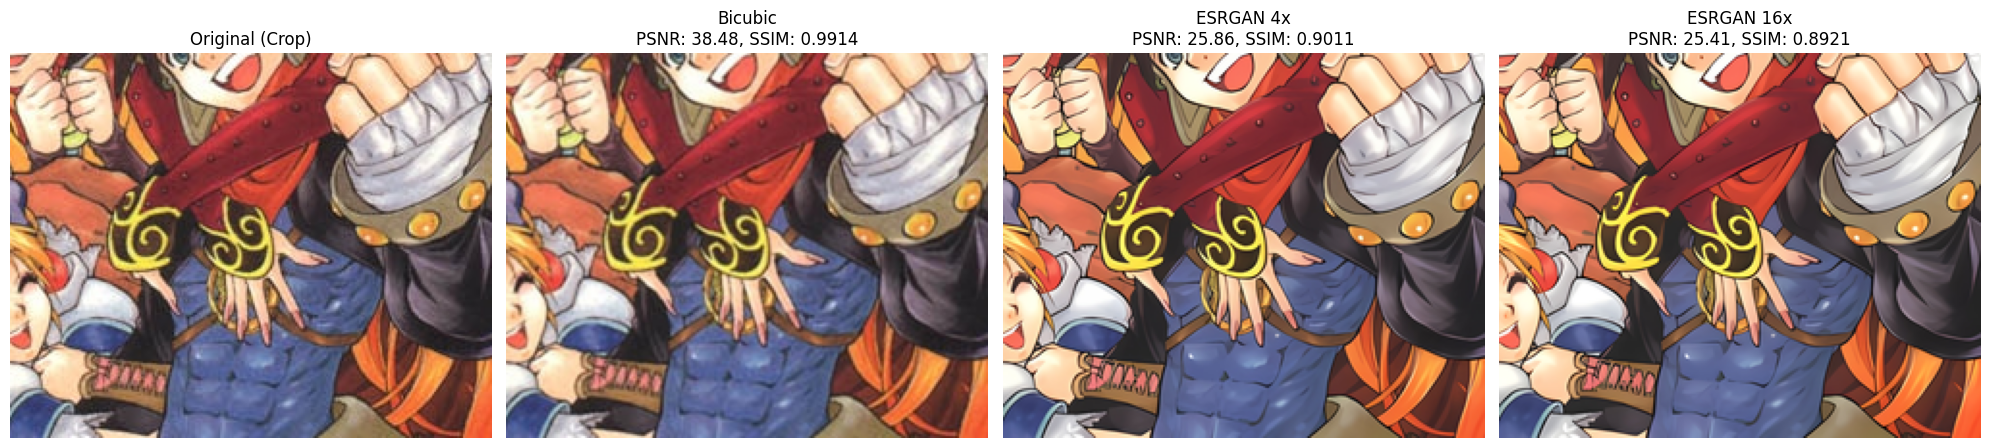

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# Abrir imagens
img_original = Image.open("/content/entrada/tamanho_original.jpeg")
img_bicubic = Image.open("/content/bicubic.jpeg").resize(img_original.size, Image.LANCZOS)
img_sr4x = Image.open("/content/resultado/tamanho_original_out.jpeg")
img_sr16x = Image.open("/content/resultado/16x/tamanho_original_out_out.jpeg")

# Crop box na imagem original
crop_box = (300, 400, 550, 600)

# Crop original e bicubic (já estão na mesma escala)
crop_original = img_original.crop(crop_box)
crop_bicubic = img_bicubic.crop(crop_box)

# Função para gerar crop da imagem SR (qualquer escala)
def crop_sr(img_sr, crop_box_original, ref_size):
    scale_x = img_sr.width / ref_size[0]
    scale_y = img_sr.height / ref_size[1]
    crop_box_sr = (
        int(crop_box_original[0] * scale_x),
        int(crop_box_original[1] * scale_y),
        int(crop_box_original[2] * scale_x),
        int(crop_box_original[3] * scale_y),
    )
    crop = img_sr.crop(crop_box_sr)
    return crop.resize((crop_box[2] - crop_box[0], crop_box[3] - crop_box[1]), Image.LANCZOS)

crop_sr4x = crop_sr(img_sr4x, crop_box, img_original.size)
crop_sr16x = crop_sr(img_sr16x, crop_box, img_original.size)

# Normalizar
def normalize(img):
    return np.array(img, dtype=np.float32) / 255.0

norm_original = normalize(crop_original)
norm_bicubic = normalize(crop_bicubic)
norm_sr4x = normalize(crop_sr4x)
norm_sr16x = normalize(crop_sr16x)

# Métricas
psnr_bicubic = psnr(norm_original, norm_bicubic, data_range=1.0)
ssim_bicubic = ssim(norm_original, norm_bicubic, data_range=1.0, channel_axis=-1)

psnr_4x = psnr(norm_original, norm_sr4x, data_range=1.0)
ssim_4x = ssim(norm_original, norm_sr4x, data_range=1.0, channel_axis=-1)

psnr_16x = psnr(norm_original, norm_sr16x, data_range=1.0)
ssim_16x = ssim(norm_original, norm_sr16x, data_range=1.0, channel_axis=-1)

# Títulos
titles = [
    "Original (Crop)",
    f"Bicubic\nPSNR: {psnr_bicubic:.2f}, SSIM: {ssim_bicubic:.4f}",
    f"ESRGAN 4x\nPSNR: {psnr_4x:.2f}, SSIM: {ssim_4x:.4f}",
    f"ESRGAN 16x\nPSNR: {psnr_16x:.2f}, SSIM: {ssim_16x:.4f}"
]

# Plot
plt.figure(figsize=(20, 5))
for i, img in enumerate([crop_original, crop_bicubic, crop_sr4x, crop_sr16x]):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
